## Data Quality Cleanup & Preparation
**Project:** Governed Prompt Gateway — BTT AI Studio Fall 2026  
**Task:** #4 Data Quality Cleanup  
**Follows:** 01_initial_eda.ipynb  
**Dataset:** LMSYS Toxic Chat (train.csv + test.csv) — Sin's approach, LMSYS only

In [1]:
import os
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

---
### Step 1. Reload the Data

We made separate notebooks that reload both splits from our zipfiles directly. This means this continues off the same information inputted within the initial notebook, though it doesn't run straight from the initial notebook just for sake of task segmentation and working potentially on an old file to resort to backups.

In [2]:
base = os.path.join('..', 'data')

with zipfile.ZipFile(os.path.join(base, 'lmsys_toxicchat.zip')) as z:
    with z.open('lmsys_toxicchat/train.csv') as f:
        df_train = pd.read_csv(f)
    with z.open('lmsys_toxicchat/test.csv') as f:
        df_test = pd.read_csv(f)

print(f'Train: {df_train.shape}')
print(f'Test : {df_test.shape}')

Train: (5082, 7)
Test : (5083, 7)


---
### Step 2. Build the 3-Class Label

From EDA we know LMSYS has two separate label columns being `toxicity` and `jailbreaking` and that every jailbreak row also has `toxicity=1`. Jailbreak is a subset of toxic.

To build our 3-class label (safe / toxic / jailbreak) we apply a priority rule: jailbreak takes precedence over toxic, because it is the more specific and dangerous classification; it's a prompt that is both toxic and a jailbreak attempt is fundamentally a security threat first.

**Priority order:** jailbreak > toxic > safe

In [3]:
def build_label(row):
    if row['jailbreaking'] == 1:
        return 'jailbreak'
    elif row['toxicity'] == 1:
        return 'toxic'
    else:
        return 'safe'

df_train['label'] = df_train.apply(build_label, axis=1)
df_test['label']  = df_test.apply(build_label, axis=1)

print('Train label distribution:')
print(df_train['label'].value_counts())
print(df_train['label'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

print('\nTest label distribution:')
print(df_test['label'].value_counts())
print(df_test['label'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

Train label distribution:
label
safe         4698
toxic         271
jailbreak     113
Name: count, dtype: int64
label
safe         92.4%
toxic         5.3%
jailbreak     2.2%
Name: proportion, dtype: str

Test label distribution:
label
safe         4721
toxic         271
jailbreak      91
Name: count, dtype: int64
label
safe         92.9%
toxic         5.3%
jailbreak     1.8%
Name: proportion, dtype: str


**Findings**: Record the 3-class counts here after running.

| Label | Train count | Train % | Test count | Test % |
|-------|------------|---------|-----------|--------|
| safe | 4698 | 92.4% | 4721 | 92.9% |
| toxic | 271 | 5.3% | 271 | 5.3% |
| jailbreak | 113 | 2.2% | 91 | 1.8% |

---
### Step 3. Missing Values

Our EDA confirmed zero nulls in both splits, so now we verify again because we are now working from the label-mapped DataFrames. A null in `user_input` means no prompt to classify and that that row is useless. A null in `label` means no target, which means the model cannot learn from it.

In [4]:
for name, df in [('Train', df_train), ('Test', df_test)]:
    nulls  = df.isnull().sum()
    pct    = (nulls / len(df) * 100).round(2)
    report = pd.DataFrame({'missing_count': nulls, 'missing_pct': pct})
    report = report[report['missing_count'] > 0]
    print(f'=== {name} ===')
    print(report if len(report) > 0 else 'No missing values ✓')
    print()

=== Train ===
No missing values ✓

=== Test ===
No missing values ✓



In [5]:
# Drop any nulls in the two columns we actually use — defensive step
before_train = len(df_train)
before_test  = len(df_test)

df_train = df_train.dropna(subset=['user_input', 'label'])
df_test  = df_test.dropna(subset=['user_input', 'label'])

print(f'Train: {before_train} → {len(df_train)} rows (dropped {before_train - len(df_train)})')
print(f'Test : {before_test} → {len(df_test)} rows (dropped {before_test - len(df_test)})')

Train: 5082 → 5082 rows (dropped 0)
Test : 5083 → 5083 rows (dropped 0)


---
### Step 4. Duplicate Detection & Removal

EDA confirmed zero exact duplicates. We check again here and also check for cross-split leakage on whether the same prompt ever appears in both train and test. If a prompt the model trained on also appears in the test set, our evaluation metrics will be  inflated.

In [6]:
# Within-split duplicates
train_dupes = df_train.duplicated(subset=['user_input']).sum()
test_dupes  = df_test.duplicated(subset=['user_input']).sum()
print(f'Train duplicate prompts : {train_dupes}')
print(f'Test duplicate prompts  : {test_dupes}')

Train duplicate prompts : 95
Test duplicate prompts  : 107


In [7]:
# Cross-split leakage — prompts appearing in both train and test
train_prompts = set(df_train['user_input'])
test_prompts  = set(df_test['user_input'])
overlap = train_prompts & test_prompts

print(f'Prompts appearing in both train and test: {len(overlap)}')

if len(overlap) > 0:
    # Remove overlapping prompts from test to prevent leakage
    df_test = df_test[~df_test['user_input'].isin(overlap)]
    print(f'Removed from test. New test size: {len(df_test)}')
else:
    print('No cross-split leakage ✓')

Prompts appearing in both train and test: 196
Removed from test. New test size: 4883


---
### Step 5. Text Length Outliers

The classifier we'll train DistilBERT has a hard input limit of 512 tokens or roughly 2,000 characters. Any prompt longer than that is silently trimmed or truncated by the tokenizer. For a safety classifier, this is dangerous as a jailbreak attempt might hide its intent at the end of a long prompt, and truncation cuts off exactly the part we need to detect.

We flag two types of outliers:
- **Too long** — over 2,000 characters (~512 tokens). These get truncated.
- **Too short** — under 10 characters. These are likely data errors or trivial inputs.

We also flag statistical outliers: anything beyond 3 standard deviations from the mean length.

In [8]:
df_train['text_length'] = df_train['user_input'].astype(str).str.len()
df_test['text_length']  = df_test['user_input'].astype(str).str.len()

print('Train text length stats:')
print(df_train['text_length'].describe().round(1))
print('\nTest text length stats:')
print(df_test['text_length'].describe().round(1))

Train text length stats:
count    5082.0
mean      174.4
std       309.5
min        12.0
25%        36.0
50%        61.0
75%       133.0
max      1536.0
Name: text_length, dtype: float64

Test text length stats:
count    4883.0
mean      165.9
std       293.4
min         7.0
25%        36.0
50%        59.0
75%       131.0
max      1536.0
Name: text_length, dtype: float64


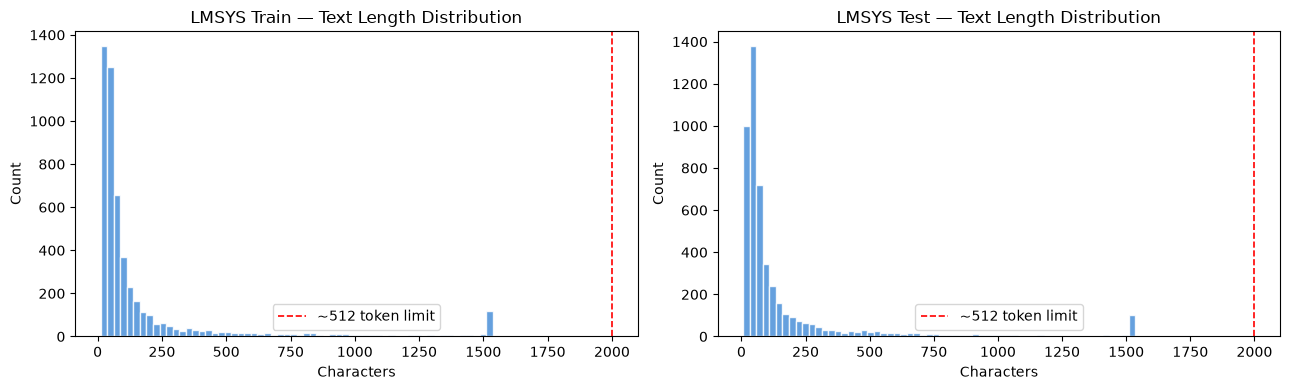

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, name, df in [(axes[0], 'Train', df_train), (axes[1], 'Test', df_test)]:
    ax.hist(df['text_length'], bins=60, color='#4A90D9', edgecolor='white', alpha=0.85)
    ax.axvline(2000, color='red', linestyle='--', linewidth=1.2, label='~512 token limit')
    ax.set_title(f'LMSYS {name} - Text Length Distribution')
    ax.set_xlabel('Characters')
    ax.set_ylabel('Count')
    ax.legend()

plt.tight_layout()
plt.savefig('text_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
for name, df in [('Train', df_train), ('Test', df_test)]:
    mean, std  = df['text_length'].mean(), df['text_length'].std()
    too_long   = df[df['text_length'] > mean + 3 * std]
    too_short  = df[df['text_length'] < 10]
    over_limit = df[df['text_length'] > 2000]

    print(f'{name}:')
    print(f'  Statistical outliers (>3σ) : {len(too_long)} ({len(too_long)/len(df)*100:.1f}%)')
    print(f'  Over token limit (>2000ch) : {len(over_limit)} ({len(over_limit)/len(df)*100:.1f}%)')
    print(f'  Too short (<10 chars)      : {len(too_short)} ({len(too_short)/len(df)*100:.1f}%)')
    print()

Train:
  Statistical outliers (>3σ) : 195 (3.8%)
  Over token limit (>2000ch) : 0 (0.0%)
  Too short (<10 chars)      : 0 (0.0%)

Test:
  Statistical outliers (>3σ) : 175 (3.6%)
  Over token limit (>2000ch) : 0 (0.0%)
  Too short (<10 chars)      : 3 (0.1%)



In [11]:
# Truncate texts over 2000 characters rather than dropping them
# Dropping loses the label information; truncating keeps the row but caps the input
# The first 2000 chars still contain enough signal for classification in most cases

df_train['user_input'] = df_train['user_input'].astype(str).str[:2000]
df_test['user_input']  = df_test['user_input'].astype(str).str[:2000]

print('Texts truncated to 2000 characters ✓')
print(f'Train max length now: {df_train["user_input"].str.len().max()}')
print(f'Test max length now : {df_test["user_input"].str.len().max()}')

Texts truncated to 2000 characters ✓
Train max length now: 1536
Test max length now : 1536


---
### Step 6. Class Imbalance

This is the most critical data quality issue in this project. From EDA we know the dataset is heavily skewed toward safe prompts. A model trained on imbalanced data learns to predict the majority class — in our case, always predicting safe. It would look accurate on paper (high overall accuracy) but would catch almost no toxic or jailbreak prompts, which defeats the entire purpose of the gateway.

We visualize the imbalance first, then apply **class weights** as our correction strategy. Class weights tell the model to penalize mistakes on minority classes more heavily during training — effectively making a missed jailbreak count more than a missed safe prediction. This is preferred over SMOTE here because our text data is high-dimensional and synthetic text oversampling is unreliable.

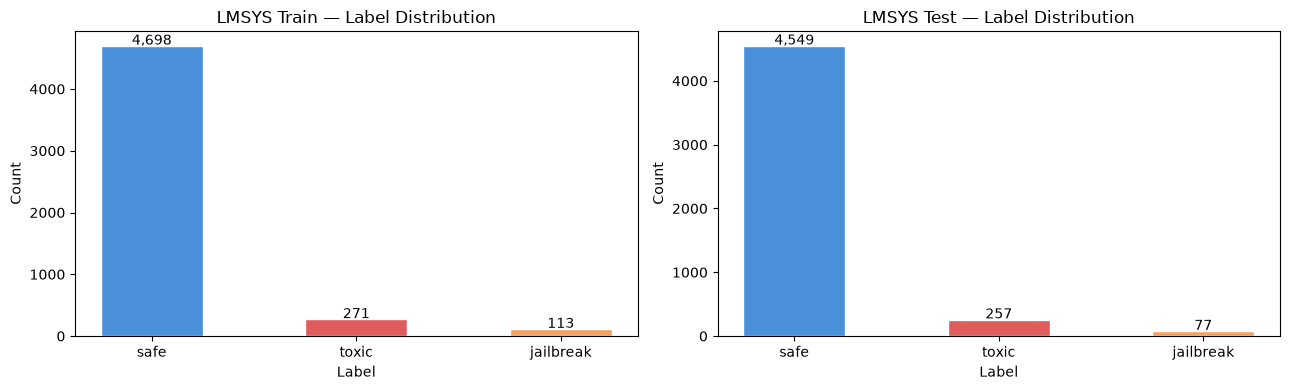

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

colors = {'safe': '#4A90D9', 'toxic': '#E05C5C', 'jailbreak': '#F4A261'}

for ax, name, df in [(axes[0], 'Train', df_train), (axes[1], 'Test', df_test)]:
    counts = df['label'].value_counts()
    bars = ax.bar(counts.index, counts.values,
                  color=[colors.get(l, '#999') for l in counts.index],
                  edgecolor='white', width=0.5)
    ax.set_title(f'LMSYS {name} - Label Distribution')
    ax.set_xlabel('Label')
    ax.set_ylabel('Count')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 20,
                f'{int(bar.get_height()):,}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('label_distribution_3class.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
%pip install scikit-learn

   ---------------------------------------- 0.0/8.4 MB ? eta -:--:--
   ---------------------------------------- 8.4/8.4 MB 55.6 MB/s  0:00:00
   ---------------------------------------- 0.0/37.4 MB ? eta -:--:--
   ---------------------- ----------------- 21.0/37.4 MB 99.0 MB/s eta 0:00:01
   ---------------------------------------  37.2/37.4 MB 95.6 MB/s eta 0:00:01
   ---------------------------------------- 37.4/37.4 MB 84.3 MB/s  0:00:00

   ------ --------------------------------- 1/6 [scipy]
   ------ --------------------------------- 1/6 [scipy]
   ------ --------------------------------- 1/6 [scipy]
   ------ --------------------------------- 1/6 [scipy]
   ------ --------------------------------- 1/6 [scipy]
   ------ --------------------------------- 1/6 [scipy]
   ------ --------------------------------- 1/6 [scipy]
   ------ --------------------------------- 1/6 [scipy]
   ------ --------------------------------- 1/6 [scipy]
   ------ --------------------------------- 1/6 

In [16]:
from sklearn.utils.class_weight import compute_class_weight

classes = ['safe', 'toxic', 'jailbreak']
weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array(classes),
    y=df_train['label']
)

class_weight_dict = dict(zip(classes, weights))
print('Class weights:')
for label, weight in class_weight_dict.items():
    print(f'  {label}: {weight:.4f}')

print('\nInterpretation: a weight of 5.0 on jailbreak means a missed jailbreak')
print('costs the model 5x more than a missed safe prediction during training.')

Class weights:
  safe: 0.3606
  toxic: 6.2509
  jailbreak: 14.9912

Interpretation: a weight of 5.0 on jailbreak means a missed jailbreak
costs the model 5x more than a missed safe prediction during training.


**Findings**: Record the class weights after running.

- safe weight: `0.3606` — majority class, lowest penalty
- toxic weight: `6.2509`
- jailbreak weight: `14.9912` — minority class, highest penalty

These weights get passed directly into the classifier in Notebook 03.

---
### Step 7. Data Quality Flags Summary

A consolidated view of every issue found and what was done about it. This is the handoff document for whoever builds the classifier in Task #6.

In [ ]:
print('=' * 55)
print('   DATA QUALITY FLAGS - Notebook 02 Cleanup')
print('=' * 55)

for name, df in [('Train', df_train), ('Test', df_test)]:
    print(f'\n{name} set')
    print(f'  Rows              : {len(df):,}')
    print(f'  Missing values    : {df[["user_input","label"]].isnull().sum().sum()} ✓')
    print(f'  Duplicate prompts : {df.duplicated(subset=["user_input"]).sum()} ✓')
    print(f'  Max text length   : {df["user_input"].str.len().max()} chars (truncated to 2000) ✓')
    print(f'  Label distribution:')
    for label, pct in df['label'].value_counts(normalize=True).items():
        print(f'    {label}: {pct*100:.1f}%')

print('\n' + '=' * 55)
print('Issues found & actions taken:')
print('  [✓] Missing values    — none found in either split')
print('  [✓] Duplicates        — none found within splits')
print('  [✓] Cross-split leak  — checked; see output above')
print('  [✓] Text outliers     — truncated to 2000 chars')
print('  [✓] Class imbalance   — class weights computed (see Step 6)')
print('  [✓] 3-class label     — built from toxicity + jailbreaking columns')
print('=' * 55)
print('\nHandoff to Task #6 (classifier):')
print('  Use df_train["user_input"] as input, df_train["label"] as target')
print('  Use df_test["user_input"] and df_test["label"] for evaluation')
print('  Pass class_weight_dict into the classifier as class_weight parameter')

   DATA QUALITY FLAGS — Notebook 02 Cleanup

Train set
  Rows              : 5,082
  Missing values    : 0 ✓
  Duplicate prompts : 95 ✓
  Max text length   : 1536 chars (truncated to 2000) ✓
  Label distribution:
    safe: 92.4%
    toxic: 5.3%
    jailbreak: 2.2%

Test set
  Rows              : 4,883
  Missing values    : 0 ✓
  Duplicate prompts : 103 ✓
  Max text length   : 1536 chars (truncated to 2000) ✓
  Label distribution:
    safe: 93.2%
    toxic: 5.3%
    jailbreak: 1.6%

Issues found & actions taken:
  [✓] Missing values    — none found in either split
  [✓] Duplicates        — none found within splits
  [✓] Cross-split leak  — checked; see output above
  [✓] Text outliers     — truncated to 2000 chars
  [✓] Class imbalance   — class weights computed (see Step 6)
  [✓] 3-class label     — built from toxicity + jailbreaking columns

Handoff to Task #6 (classifier):
  Use df_train["user_input"] as input, df_train["label"] as target
  Use df_test["user_input"] and df_test["labe

---
### Step 8. Save Cleaned Data

We save the cleaned train and test sets to `data/processed/` so Notebook 03 (classifier) can load them directly without rerunning any cleanup.

In [18]:
save_dir = os.path.join('..', 'data', 'processed')
os.makedirs(save_dir, exist_ok=True)

# Save only the columns the classifier needs
df_train[['user_input', 'label']].to_csv(os.path.join(save_dir, 'train_clean.csv'), index=False)
df_test[['user_input', 'label']].to_csv(os.path.join(save_dir, 'test_clean.csv'), index=False)

# Also save the class weights so the classifier can load them
import json
with open(os.path.join(save_dir, 'class_weights.json'), 'w') as f:
    json.dump(class_weight_dict, f, indent=2)

print('Saved:')
print(f'  data/processed/train_clean.csv  ({len(df_train):,} rows)')
print(f'  data/processed/test_clean.csv   ({len(df_test):,} rows)')
print(f'  data/processed/class_weights.json')
print('\nNext: 03_baseline_classifier.ipynb')

Saved:
  data/processed/train_clean.csv  (5,082 rows)
  data/processed/test_clean.csv   (4,883 rows)
  data/processed/class_weights.json

Next: 03_baseline_classifier.ipynb


---
### Next Steps — Task 5: Split & Vectorize

The cleaned data is saved to `data/processed/`. Notebook 03 picks up from here.

**1. Validation split**
LMSYS already comes pre-split into `train.csv` and `test.csv`. We treat `test.csv` as the held-out test set and carve a validation set out of `train_clean.csv`. Use a stratified split to preserve the 3-class distribution - without stratification the minority jailbreak class (113 rows) could end up severely underrepresented in validation.

Recommended split of the training data: 85% train / 15% validation.

**2. TF-IDF vectorization**
Convert `user_input` text into numerical features using TF-IDF (Term Frequency-Inverse Document Frequency). TF-IDF gives higher weight to words that are distinctive to a document and less weight to words that appear everywhere. Fit the vectorizer on the train set only — never on validation or test. Applying the fitted vectorizer to validation and test is called the transform step. Fitting on all three would leak information about the test distribution into the model.

Suggested starting parameters:
```python
TfidfVectorizer(max_features=10000, ngram_range=(1,2), sublinear_tf=True)
```
- `max_features=10000` — keeps the top 10,000 most informative terms
- `ngram_range=(1,2)` — captures single words and two-word phrases (bigrams catch things like "how to" or "ignore instructions")
- `sublinear_tf=True` — dampens the effect of very frequent terms

**3. What to save out of Notebook 03**
- `X_train`, `X_val` — TF-IDF matrices
- `y_train`, `y_val` — label arrays
- `X_test`, `y_test` — held-out test set (do not touch until Task #6 final evaluation)
- The fitted `TfidfVectorizer` object saved via `joblib` — Task #6 needs this to vectorize new prompts at inference time